In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# analyze fft results

In [3]:
# load simulation results
fdname = '../simulation_results/frequency_modulation/w_fc/'

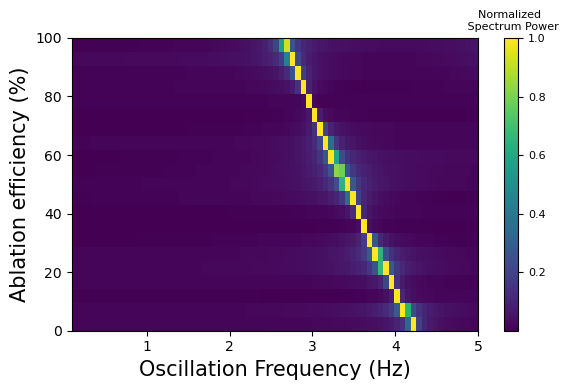

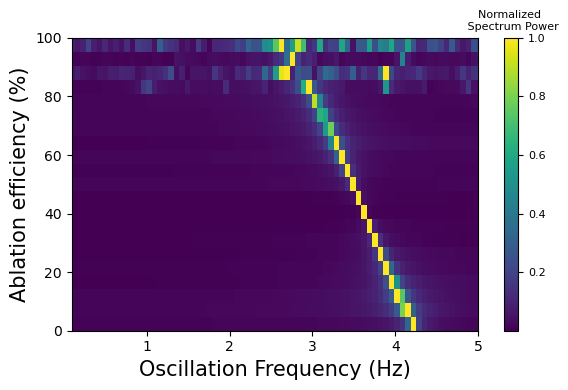

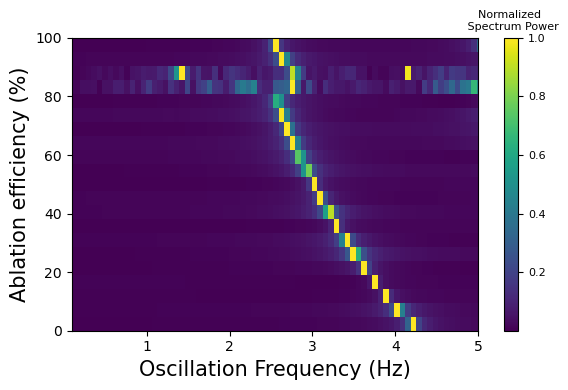

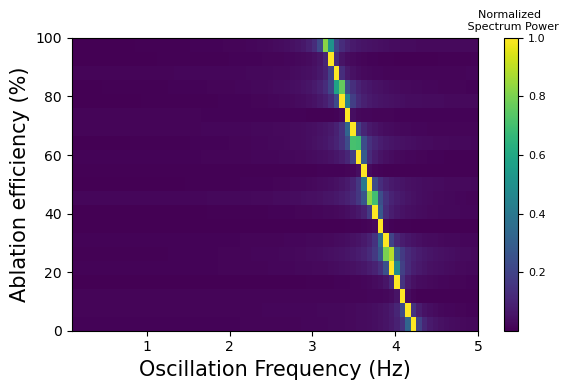

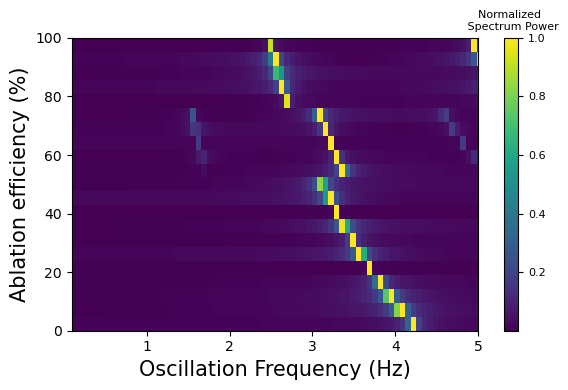

In [5]:
Nrep = 50
Npts = 21

for c_ind in ['V2a','V1','V2a_V1','V2b','V2a_V2b']:
    
    plt.figure(figsize=(6,4))
    
    # select modulation
    modulation = 'ablation'
    # modulation = 'activation'
    
    catname = 'var_%s_mode_%s'%(c_ind,modulation)
    
    if modulation == 'ablation':
        pararan = np.linspace(1,0,Npts)*100
        all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_fftresult.txt'% \
                                  (catname,1-pararan[0]/100,1-pararan[-1]/100,Nrep,Npts))
        freqvalues = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_fftfreq.txt'%
                              (catname,1-pararan[0]/100,1-pararan[-1]/100,Nrep,Npts))
    elif modulation =='activation':
        pararan = np.linspace(0,5.0,Npts)
        all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_fftresult.txt'%
                              (catname,pararan[0],pararan[-1],Nrep,Npts))
        freqvalues = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_fftfreq.txt'%
                              (catname,pararan[0],pararan[-1],Nrep,Npts))
    all_data = all_data.reshape(Nrep,Npts,-1)

# only one trial and normalize to total power
    mean_mat = all_data[4,:,1:]
#     plt.figure(figsize=(8,8))
  
    if modulation == 'ablation':
        plt.imshow((mean_mat.T/np.max(mean_mat,axis=1)).T,extent=[freqvalues[1],freqvalues[-1],0,100],aspect="auto")
        plt.xlim([0.1,5])
        plt.ylabel('Ablation efficiency (%)',fontsize=15)
        
    elif modulation == 'activation':
#         mean_mat[8:] = None
        plt.imshow((mean_mat.T/np.max(mean_mat,axis=1)).T,extent=[freqvalues[1],freqvalues[-1],0,5],aspect="auto",origin = 'lower')
        if c_ind in ['V2a','V2a_V1','V2a_V2b']:
            plt.xlim([0.1,12])
        else:
            plt.xlim([0.1,5])
        plt.ylabel('Addition to input current (muA)',fontsize=15)
        
    plt.xlabel('Oscillation Frequency (Hz)',fontsize=15)


    clb=plt.colorbar()
    clb.ax.tick_params(labelsize=8) 
    clb.ax.set_title('Normalized \n Spectrum Power',fontsize=8)
    
    plt.tight_layout()